<a href="https://colab.research.google.com/github/Yashcode007/masters_in_ai/blob/deep_learning_wb_84520/computational_graphs_2(6)_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Computational Graphs helps to compute the gradient descent very very efficiently(with sort of no direct input from us).

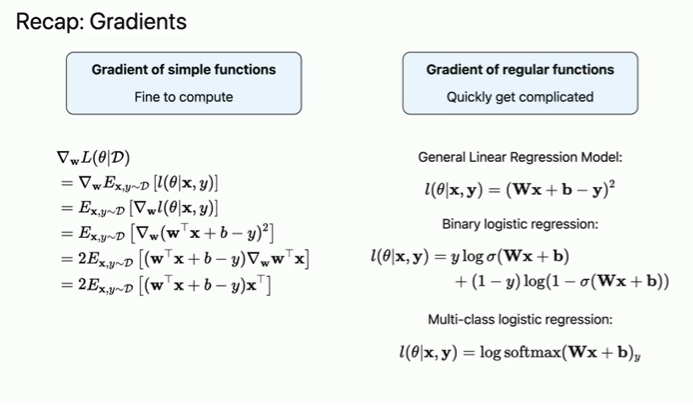

Now , we are computing the following function .


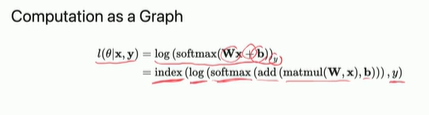

In the second line (of =) , we have only written about the expansion of the following function written(just as if we needed to code )

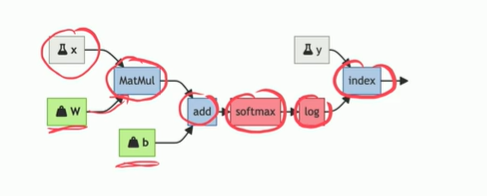

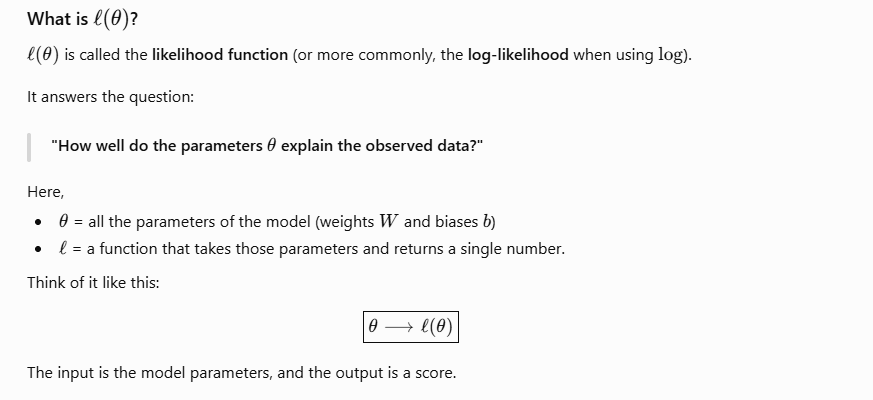

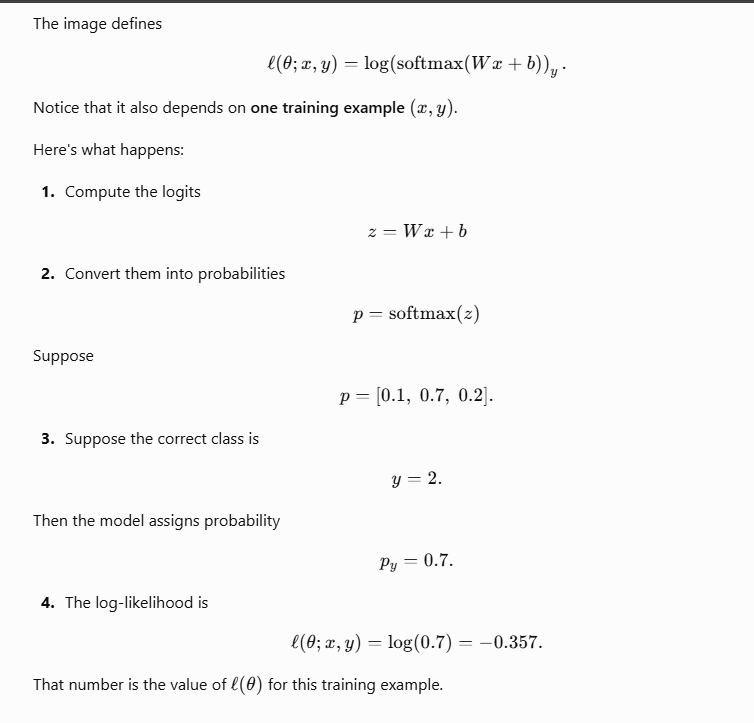

The above diagram is just a way to represent the upper function in some sort of graph / diagram

In [11]:
import torch

In [13]:
y = torch.rand(10)
x = torch.rand(10, requires_grad=True)

print(y)
print(x)

tensor([0.3628, 0.3588, 0.1717, 0.3999, 0.0627, 0.2989, 0.5872, 0.6325, 0.2606,
        0.6141])
tensor([0.7308, 0.5737, 0.2571, 0.4634, 0.8333, 0.7815, 0.3857, 0.6487, 0.0188,
        0.3624], requires_grad=True)


In [14]:
(y**2).mean()

tensor(0.1733)

In [16]:
b = (x**2).mean()
print(b)
b.backward()

tensor(0.3151, grad_fn=<MeanBackward0>)


In [20]:
print(x/10 * 2)
print(x.grad)

tensor([0.1462, 0.1147, 0.0514, 0.0927, 0.1667, 0.1563, 0.0771, 0.1297, 0.0038,
        0.0725], grad_fn=<MulBackward0>)
tensor([0.1462, 0.1147, 0.0514, 0.0927, 0.1667, 0.1563, 0.0771, 0.1297, 0.0038,
        0.0725])


In [12]:
x = torch.rand(2**20, requires_grad=True, device="cuda")
torch.cuda.memory_allocated() / 1024 / 1024

24.0009765625

In [13]:
b = x
for _ in range(100):
  b = torch.relu(b)
torch.cuda.memory_allocated()/1024/1024

412.0009765625

In [14]:
b.sum().backward()
torch.cuda.memory_allocated()/1024/1024

20.0009765625

4 of them are used to store b(which is the output of this 100 relu) . 4 is used to store the input . 4 is used to store the gradient

So , once we call the backward , the entire computation graph sort of collapses and all the memory that was allocated (to compute and build this graph) is gone . And thus , we can never call backward on the graph twice .